# 🎯 Goal:
## Predict whether a passenger survived the Titanic disaster based on features like age, gender, and class.

# 📦 Required Libraries: 

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 🧾 Step 1: Load Dataset

In [7]:
# Load Titanic dataset from seaborn
df = sns.load_dataset('titanic')
print(df.head())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


# 🔍 Step 2: Preprocessing

In [8]:
# Select features and target
df = df[['sex', 'age', 'pclass', 'survived']]

# Drop missing values
df.dropna(inplace=True)

# Convert categorical to numerical
df['sex'] = df['sex'].map({'male': 0, 'female': 1})

# Features and label
X = df[['sex', 'age', 'pclass']]
y = df['survived']

# ✂️ Step 3: Train-Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 🤖 Step 4: Train Logistic Regression Model

In [10]:
model = LogisticRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# 📏 Step 5: Evaluation

Accuracy: 0.7482517482517482


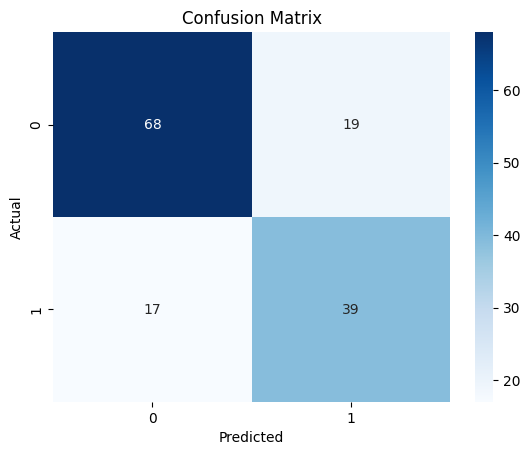

              precision    recall  f1-score   support

           0       0.80      0.78      0.79        87
           1       0.67      0.70      0.68        56

    accuracy                           0.75       143
   macro avg       0.74      0.74      0.74       143
weighted avg       0.75      0.75      0.75       143



In [11]:
# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification report
print(classification_report(y_test, y_pred))

# 🧠 Optional: Predict a Single Passenger

In [12]:
# Predict female, age 22, class 2
sample = pd.DataFrame([[1, 22, 2]], columns=['sex', 'age', 'pclass'])
prediction = model.predict(sample)
print("Survival Prediction (1=Survived):", prediction[0])

Survival Prediction (1=Survived): 1


# 📘 Logistic Regression Summary:
## Outputs probabilities using a sigmoid function.

## Used for binary classification (e.g., 0 or 1).

## Evaluated using accuracy, confusion matrix, precision, recall, F1-score.